# **Task HD1** 
## Analyzing YouTube Video Data from News Publishers

##### This task focuses on analyzing YouTube videos about a news topic (e.g., Covid-19) published by at least 4 English news publishers (e.g., BBC, Fox News, ...) from a start date to an end date. You will need to specify the news topic and the list of keywords to search for the videos about that topic on YouTube. Also, you will need to extract the channel IDs of the news publishers using the function get_channel_info() given to you in the attached "collect.ipynb" file. All settings need to be specified in Section B (Settings) of "collect.ipynb" and also copied into Section B (Settings) of this jupyter notebook (HD1.ipynb). Please note the terms "News Publisher" and "Cahnnel" have been used interchangably in this task (each news publisher has a channel - if a news publisher has more than one channels on YouTube, pick any and state that in your TaskCompletionReport). The following instructions convey important information about the task. Please **read them carefully** and complete the task. If you need any clarification please    
<img src="youtube.png" alt="SIT112 Avocado!" width="1800" height="200">

### A. Instructions

#### Attachments
* directions.pdf
* collect.ipynb
* credentials-sample.ini
* video-presentation-guideline.pdf

#### Get Started 
0. Please watch [this video](https://www.youtube.com/watch?v=N9CT6Ggh0oE) about Sentiment Analysis.
1. Rename the "credentials-sample.ini" file to "credentials.ini" and follow the instructions. 
2. Creat your YouTube API key and assign it to developer_key in the credentials.ini file. You will need the YouTube API key to get access to the YouTube API (collect the data). See the following video: https://youtu.be/N18czV5tj5o (the video is not up to date; the instrucitons might be sighly different. You can view the following link for more details: https://developers.google.com/youtube/v3/getting-started). Please note Projects that enable the YouTube Data API have a default quota allocation of 10,000 units per day; to make an efficient use of your quota, please avoid multiple excecutions of the "collect.ipynb" file: https://developers.google.com/youtube/v3/guides/quota_and_compliance_audits. 
3. To work with the YouTube API (send queries), you need to install Google API Python Client using: "conda install google-api-python-client" 
#### Specify the news topic and news publishers (channels)
4. Choose a news topic (e.g., Covid-19) and a list of keywords to be used for finding videos about that topic. You can extract the keywords by looking at some sample video titles. 
5. Choose at least 4 popular English news publishers (e.g., BBC, Fox News).
6. Extract, manually, the video IDs of sample videos from different news publishers (channels). You can do so by clicking on the share button for each video. 
7. Extract the Channel IDs of the videos using the get_channel_info() function in collect.ipynb 
#### Collect the Videos and Comments using "collect.ipynb" 
8. Specify the Channel IDs and names in the Settings section of the attached collect.ipynb file (CHANNELS = {...})
9. Specify the list keywords in the Settings section of the attached collect.ipynb file (KEYWORDS = [...])
10. Specify the START_DATE and END_DATE in the Settings section of the attached collect.ipynb file
11. Specify the MAX_VIDEOS such that you can extract **at least 20 videos per news publisher (channel)**. Make sure for your specified topic, **at least 300 comments per news publisher (channel)** can be collected. Please note some publishers might have disabled comments.
12. Please **do not make any changes to the "collect.ipynb" file**
13. Execute the collect.ipynb file to collect the videos (will be stored in videos.csv) and the comments on those videos (will be stored in comments.csv).
#### Complete the Task
14. <font color='red'> Choose only 1 question from Section E</font>, and answer it based on the hints. Please note, for each question, you must **briefly discuss your observations** based on the results.
15. Please note **there is no unique solution** for most questions; if you need to make any assumptions, **state your assumptions** in the comments and in your TaskCompletionReport and answer the question accordingly. Please also note, **if something has not been clearly stated in a question (e.g., the type of visualization, etc) it means you are allowed to make your own choice**. 
16. **Read the attached "video-presentation-guideline.pdf"** carefully and record a video clip (based on video-presentation-guideline.pdf) that presents your completed task. Upload the video on a video repository such as YouTube (or any other preferred repository) and provide the link in the TaskCompletionReport. 
17. Complete the TaskCompletionReport form.

#### Submit the Task
18. Please make sure you have copied the settings from collect.ipynb into your solution file (HD1.ipynb), under section B (settings).  
19. Please make sure you have executed and saved all the cells in your jupyter notebook without any error; otherwise, your submission may not be flagged as complete. 
20. Please make sure you have included the link to the video rcording of your presentation in your TaskCompletionReport. 
21. Submit (1) the TaskCompletionReport as a "PDF" file and (2) your solution file (HD1.ipynb) as an "ipynb" file (do not zip/combine them). Please do not include "collect.ipynb" in your submission. 

#### <font color ='red'>Attend the Interview </font>
22. Please attend your interview - on week 11 - during the workshop you are enrolled in. 
23. Please make sure you have submitted your task via OnTrack before the interview; you can still resubmit by the end of Week 12 if any changes are needed. 
24. During the interview, you will be asked questions about your submission and might be directed to make changes to your code and explain their impacts on the results/observations. 

Good luck :)

### B. Settings
Copy your settings from Section B of the "collect.ipynb" file below (as Python comments).

In [5]:
VIDEOS_FILE = "videos.csv"
COMMENTS_FILE = "comments.csv"
CREDENTIALS_FILE = 'credentials.ini'

START_DATE = datetime(2020, 1, 1)
END_DATE = datetime(2023, 1, 1)

KEYWORDS = ['coronavirus', 'covid', 'covid-19', 'pandemic']

CHANNELS = {
    'UCXIJgqnII2ZOINSWNOGFThA' : 'Fox News',
    'UC16niRr50-MSBwiO3YDb3RA' : 'BBC News',
    'UCupvZG-5ko_eiXAupbDfxWw' : 'CNN',
    'UCaXkIU1QidjPwiAYu6GcHjg' : 'MSNBC'
}

MAX_VIDEOS = 50

QUERY = f"intitle:{','.join(KEYWORDS)}"

### C. Imports
You need to import the following libraries. Install the libraries using "conda install ... or pip install ..." if they have not been installed on your machine. For example you can install google api python client by executing "conda install google-api-python-client"

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from googleapiclient.discovery import build
from googleapiclient.errors import HttpError
from datetime import datetime
import os
from configparser import ConfigParser
import re
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from wordcloud import WordCloud
from langdetect import detect
import langdetect
from textblob import TextBlob
import calendar
import matplotlib.dates as mdates
from matplotlib.dates import DateFormatter
from prettytable import PrettyTable
from tabulate import tabulate
import numpy as np
from collections import defaultdict
import warnings
from nltk.stem import WordNetLemmatizer

warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sramn\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\sramn\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [3]:
pip install wordcloud 

Note: you may need to restart the kernel to use updated packages.


### D. Clean and Prepare the Data

##### D.1. Write Python code that cleans the data for analyzing the videos and comments.

In [6]:
# I performed additional cleaning here to make sure the datasets are ready for sentiment analysis.

videos_df = pd.read_csv(VIDEOS_FILE)
comments_df = pd.read_csv(COMMENTS_FILE)

videos_df = videos_df.drop_duplicates()
comments_df = comments_df.drop_duplicates()

videos_df = videos_df.dropna(subset=['video_id', 'video_title', 'channel_title'])
comments_df = comments_df.dropna(subset=['video_id', 'comment_id', 'comment_text'])

video_numeric_cols = ['view_count', 'like_count', 'comment_count']

for col in video_numeric_cols:
    videos_df[col] = pd.to_numeric(videos_df[col], errors='coerce').fillna(0).astype(int)

comments_df['comment_like_count'] = pd.to_numeric(
    comments_df['comment_like_count'],
    errors='coerce'
).fillna(0).astype(int)

print("Additional data cleaning completed successfully.")
print("Number of videos:", len(videos_df))
print("Number of comments:", len(comments_df))

Additional data cleaning completed successfully.
Number of videos: 200
Number of comments: 4274


##### D.2. Write Python code that prepares the data for analyzing the videos and comments.

In [7]:
# I converted the date columns and prepared the datasets for analysis.

videos_df['published_at'] = pd.to_datetime(videos_df['published_at'], errors='coerce')
videos_df['published_at_week'] = videos_df['published_at'].dt.strftime('%Y-%m-%W')
videos_df['published_at_month'] = videos_df['published_at'].dt.strftime('%Y-%m')
videos_df['published_at_year'] = videos_df['published_at'].dt.strftime('%Y')

comments_df['comment_date'] = pd.to_datetime(comments_df['comment_date'], errors='coerce')
comments_df['comment_date_week'] = comments_df['comment_date'].dt.strftime('%Y-%m-%W')
comments_df['comment_date_month'] = comments_df['comment_date'].dt.strftime('%Y-%m')
comments_df['comment_date_year'] = comments_df['comment_date'].dt.strftime('%Y')

def duration_to_seconds(duration):
    if pd.isna(duration):
        return 0
    
    pattern = re.compile(r'PT(?:(\d+)H)?(?:(\d+)M)?(?:(\d+)S)?')
    match = pattern.match(str(duration))
    
    if not match:
        return 0
    
    hours = int(match.group(1)) if match.group(1) else 0
    minutes = int(match.group(2)) if match.group(2) else 0
    seconds = int(match.group(3)) if match.group(3) else 0
    
    return hours * 3600 + minutes * 60 + seconds

videos_df['duration'] = videos_df['duration'].apply(duration_to_seconds)

videos = videos_df.copy()
comments = comments_df.copy()

videos_comments = pd.merge(videos, comments, on='video_id', how='inner')

print("Data preparation completed successfully.")
print("Videos shape:", videos.shape)
print("Comments shape:", comments.shape)
print("Merged dataset shape:", videos_comments.shape)

Data preparation completed successfully.
Videos shape: (200, 20)
Comments shape: (4274, 10)
Merged dataset shape: (4274, 29)


##### D.3. Write Python code that takes a text input and returns its sentiment (polarity) score and sentiment category (positive, negative, neutral)

In [8]:
# I used TextBlob to calculate sentiment polarity scores and sentiment categories.

def get_sentiment_score(text):
    if pd.isnull(text):
        return 0
    else:
        return TextBlob(str(text)).sentiment.polarity

def get_sentiment(text):
    if pd.isnull(text):
        return 'neutral'
    else:
        polarity = TextBlob(str(text)).sentiment.polarity
        
        if polarity > 0:
            return 'positive'
        elif polarity < 0:
            return 'negative'
        else:
            return 'neutral'

print("Sentiment functions created successfully.")

Sentiment functions created successfully.


### E. Analyze the Videos and Comments
* Please make sure you have watched [this video](https://www.youtube.com/watch?v=N9CT6Ggh0oE) and understood the concept of Sentiment Analysis.
* Choose <font color ='red'>(only) 1 </font> of the following questions and write Python code to answer it. 
* Please note you must (briefly) discuss your observations. 
* Use function get_sentiment_score() to identify the sentiment (polarity) score of the video titles or comments.
* Use function get_sentiment() to identify the sentiment categories (positive, negative, neutral) of the video titles or comments.
* Please note the comments are provided to partially guide you; you are not required to strictly follow them. 


##### E.1. What is the monthly distribution of the positive, negative, and neutral sentiments in the video titles and comments from Jan 2020 to Jan 2021? Use visualization to answer this question for different news publishers (channels) and discuss your observations. 

In [6]:
# load the data

# extract year and month from published_at and comment_date columns

# apply the get_sentiment function to the video titles to get the sentiment

# apply the get_sentiment function to the comments to get the sentiment

# define start and end date for data analysis

# ...


##### E.2. Use regression analysis with visualization to test the following hypothesises:

* H1: There is a meaningful relationship between the sentiment of a video title and the sentiments of its corresponding comments.  
* H2: There is a meaningful relationship between the video likes and the sentiments of its corresponding comments.
* H3: There is a meaningful relationship between the duration of a video and the sentiments of its corresponding comments.

In [9]:
# I created three regression plots to visually test the three hypotheses.

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# H1: Title sentiment vs average comment sentiment
sns.regplot(
    data=video_sentiment_analysis,
    x='title_sentiment_score',
    y='avg_comment_sentiment_score',
    ax=axes[0],
    scatter_kws={'alpha': 0.6}
)

axes[0].set_title('H1: Video Title Sentiment vs Comment Sentiment')
axes[0].set_xlabel('Video Title Sentiment Score')
axes[0].set_ylabel('Average Comment Sentiment Score')

# H2: Video likes vs average comment sentiment
sns.regplot(
    data=video_sentiment_analysis,
    x='like_count',
    y='avg_comment_sentiment_score',
    ax=axes[1],
    scatter_kws={'alpha': 0.6}
)

axes[1].set_title('H2: Video Likes vs Comment Sentiment')
axes[1].set_xlabel('Video Like Count')
axes[1].set_ylabel('Average Comment Sentiment Score')

# H3: Video duration vs average comment sentiment
sns.regplot(
    data=video_sentiment_analysis,
    x='duration',
    y='avg_comment_sentiment_score',
    ax=axes[2],
    scatter_kws={'alpha': 0.6}
)

axes[2].set_title('H3: Video Duration vs Comment Sentiment')
axes[2].set_xlabel('Video Duration in Seconds')
axes[2].set_ylabel('Average Comment Sentiment Score')

plt.tight_layout()
plt.show()

,video_id,title_sentiment_score,video_title,channel_title,like_count,duration,avg_comment_sentiment_score
0,-2h2bQYO-0E,0.0,coronavirus pandemic cases continue to sweep a...,MS NOW,1109,526,0.171873
1,-RRq7BbOzuU,0.4,two coronavirus cases confirmed in uk bbc news,BBC News,3168,145,0.014938
2,-SV8a9lGGk8,0.0,americans see massive disruptions to daily lif...,MS NOW,1294,332,-0.189591
3,-_1gxrkgIJU,0.0,rise in vaccinations in states hardest hit by ...,MS NOW,1025,608,0.182045
4,-r6mUnerPtc,0.5,barstool sports founder on making the most of ...,Fox News,1151,242,0.075379


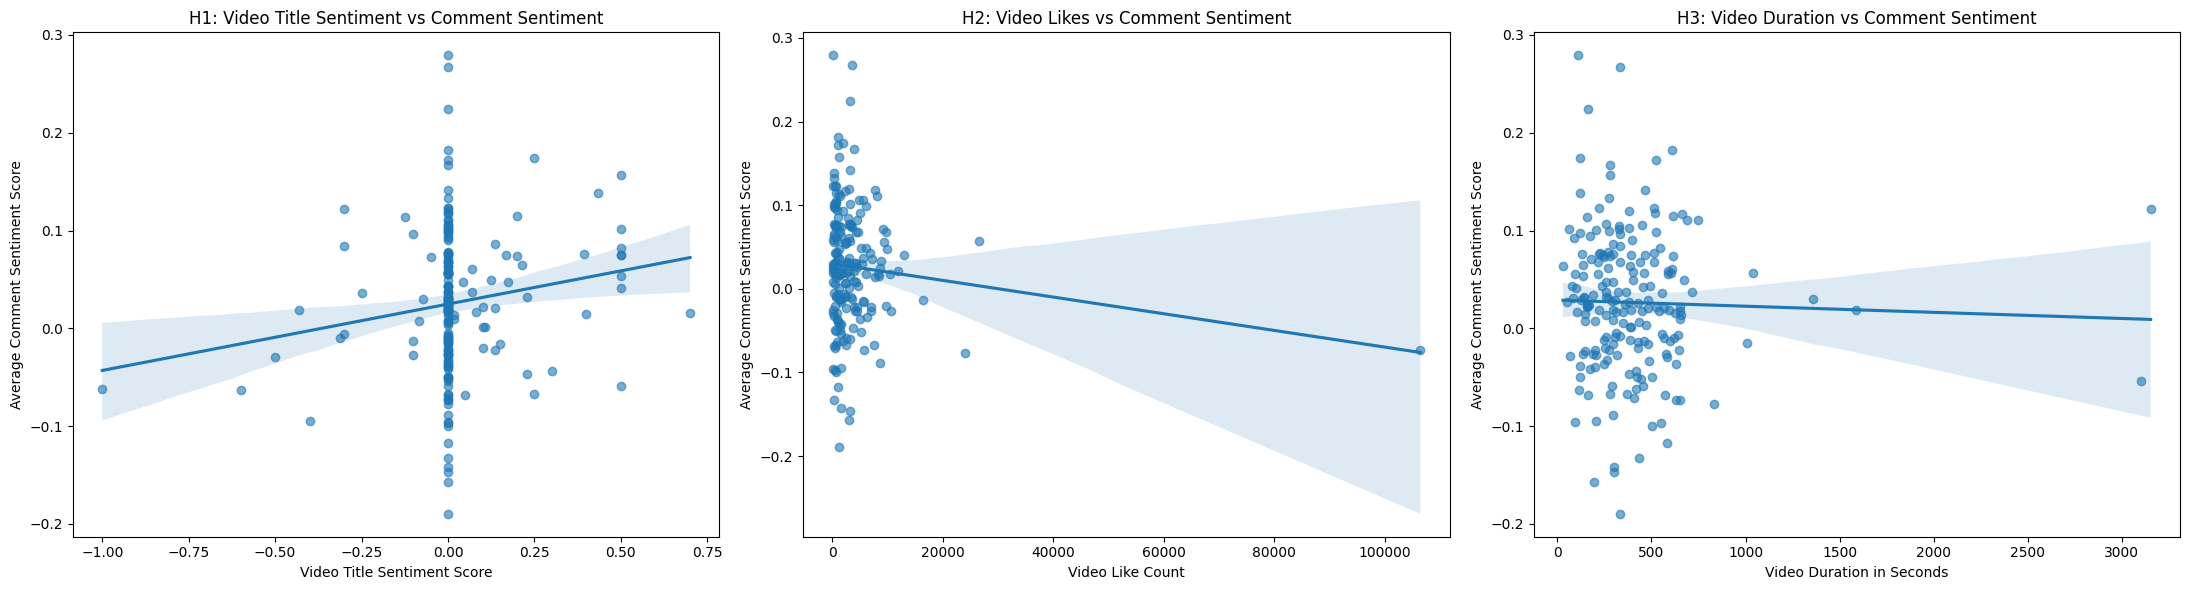

In [10]:
# I created three regression plots to visually test the three hypotheses.

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# H1: Title sentiment vs average comment sentiment
sns.regplot(
    data=video_sentiment_analysis,
    x='title_sentiment_score',
    y='avg_comment_sentiment_score',
    ax=axes[0],
    scatter_kws={'alpha': 0.6}
)

axes[0].set_title('H1: Video Title Sentiment vs Comment Sentiment')
axes[0].set_xlabel('Video Title Sentiment Score')
axes[0].set_ylabel('Average Comment Sentiment Score')

# H2: Video likes vs average comment sentiment
sns.regplot(
    data=video_sentiment_analysis,
    x='like_count',
    y='avg_comment_sentiment_score',
    ax=axes[1],
    scatter_kws={'alpha': 0.6}
)

axes[1].set_title('H2: Video Likes vs Comment Sentiment')
axes[1].set_xlabel('Video Like Count')
axes[1].set_ylabel('Average Comment Sentiment Score')

# H3: Video duration vs average comment sentiment
sns.regplot(
    data=video_sentiment_analysis,
    x='duration',
    y='avg_comment_sentiment_score',
    ax=axes[2],
    scatter_kws={'alpha': 0.6}
)

axes[2].set_title('H3: Video Duration vs Comment Sentiment')
axes[2].set_xlabel('Video Duration in Seconds')
axes[2].set_ylabel('Average Comment Sentiment Score')

plt.tight_layout()
plt.show()

In [13]:
# I calculated correlation values to support the visual interpretation of the regression plots.

h1_corr = video_sentiment_analysis['title_sentiment_score'].corr(
    video_sentiment_analysis['avg_comment_sentiment_score']
)

h2_corr = video_sentiment_analysis['like_count'].corr(
    video_sentiment_analysis['avg_comment_sentiment_score']
)

h3_corr = video_sentiment_analysis['duration'].corr(
    video_sentiment_analysis['avg_comment_sentiment_score']
)

correlation_results = pd.DataFrame({
    'Hypothesis': [
        'H1: Title sentiment and comment sentiment',
        'H2: Likes and comment sentiment',
        'H3: Duration and comment sentiment'
    ],
    'Correlation Value': [h1_corr, h2_corr, h3_corr]
})

correlation_results

,Hypothesis,Correlation Value
0,H1: Title sentiment and comment sentiment,0.164417
1,H2: Likes and comment sentiment,-0.113563
2,H3: Duration and comment sentiment,-0.030583


In [14]:
# I also checked the overall sentiment category distribution of comments.

comment_sentiment_summary = comments['comment_sentiment_category'].value_counts().reset_index()
comment_sentiment_summary.columns = ['Sentiment Category', 'Number of Comments']

comment_sentiment_summary

,Sentiment Category,Number of Comments
0,positive,1577
1,neutral,1552
2,negative,1145


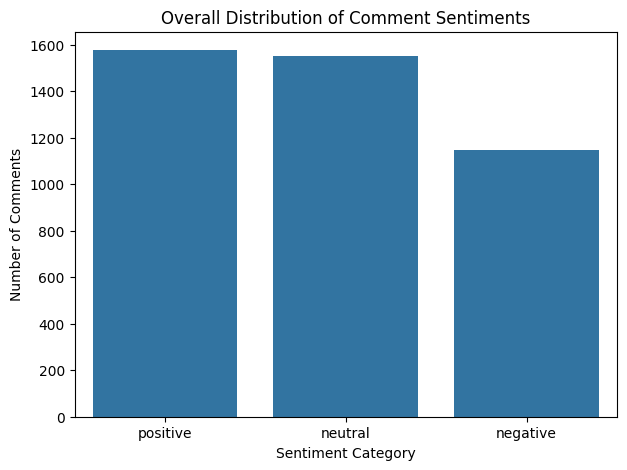

In [15]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=comment_sentiment_summary,
    x='Sentiment Category',
    y='Number of Comments'
)

plt.title('Overall Distribution of Comment Sentiments')
plt.xlabel('Sentiment Category')
plt.ylabel('Number of Comments')

plt.show()

##### E.3. Check if the following hypothesis is true: Video titles that contain certain words are more likely to elicit certain sentiments in the comments. Use visualization and discuss your observations. Use function get_sentiment_score().

Approach: Use natural language processing (NLP) techniques to clean the video titles and count the occurrence of words in them. Group the video titles by their associated sentiment categories (positive, negative, neautral) and filter out words that are frequent across all sentiment categories. You can visualize the relationship between sentiment and word prevalence by creating word clouds for each sentiment category.


In [8]:
# This question is slightly more challenging than E.1 and E.2 (please note you are required to asnwer only one of the questions)
